In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum
from dataclasses import dataclass
import math
from tqdm import tqdm


from tiles import *
from utils import *
import solver as solver_import

sns.set_context("notebook", font_scale=0.7)

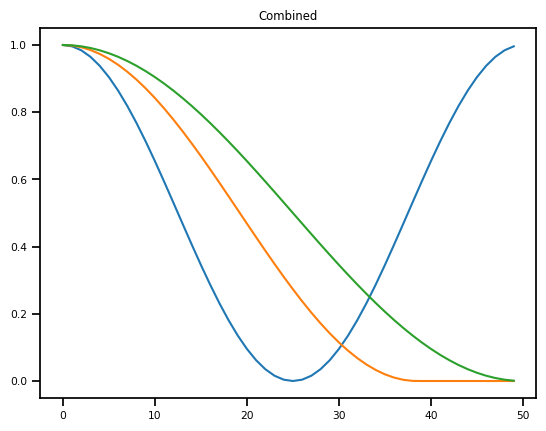

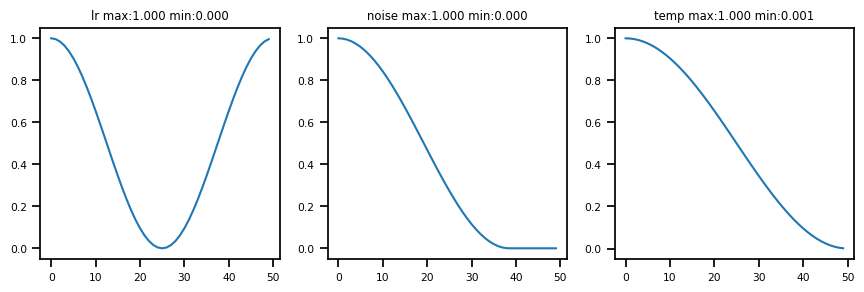

In [2]:
class Schedule:
    def __init__(self, max_iter):
        self.max_iter = max_iter

    def lr(self,x):
        x /= self.max_iter
        return np.cos(x*np.pi)**2
    def noise(self,x):
        x /= self.max_iter
        return np.cos(min(x*1.3,1)*np.pi/2)**2
    def temp(self,x):
        x /= self.max_iter
        return np.cos(x*np.pi/2)**2

schedule = Schedule(50)
plot_schedule(schedule)

In [3]:
import importlib
importlib.reload(solver_import) # Fast reaload

BOX_SIZE = 30
INPUT_POS = (15,15)
OUT_POS = (29, 0)
NEG_INF = -500.0

cost_tensor = torch.tensor([data.cost for _,data in DEFAULT_TILE_DATA.items()]).reshape(1,1,-1).expand(BOX_SIZE,BOX_SIZE,-1)

start_tensor = torch.zeros(BOX_SIZE,BOX_SIZE)
start_tensor[INPUT_POS[0], INPUT_POS[1]] = 100

end_mask = torch.zeros(BOX_SIZE,BOX_SIZE,dtype=torch.bool)
end_mask[OUT_POS[0], OUT_POS[1]] = 1

sim = solver_import.FactorioSim(BOX_SIZE, DEFAULT_TILE_DATA)
sim.set_start(start_tensor)
sim.set_end_mask(end_mask)

In [4]:
torch.autograd.set_detect_anomaly(False, check_nan=False)

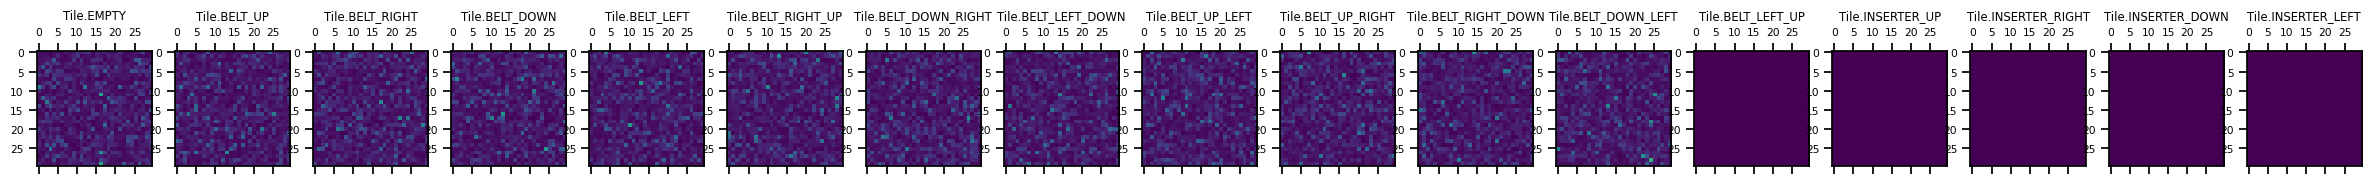

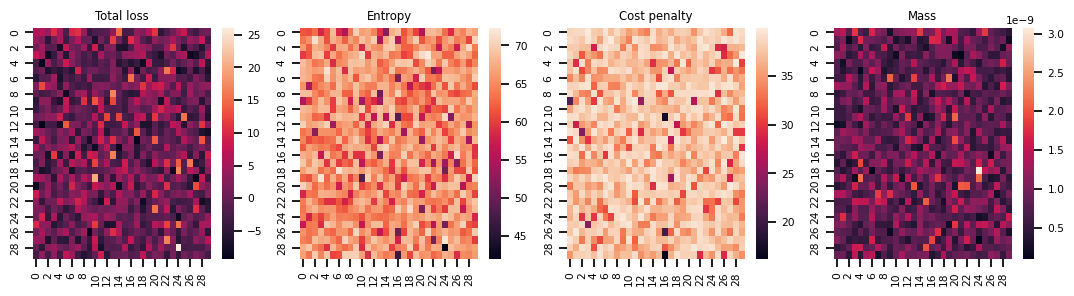

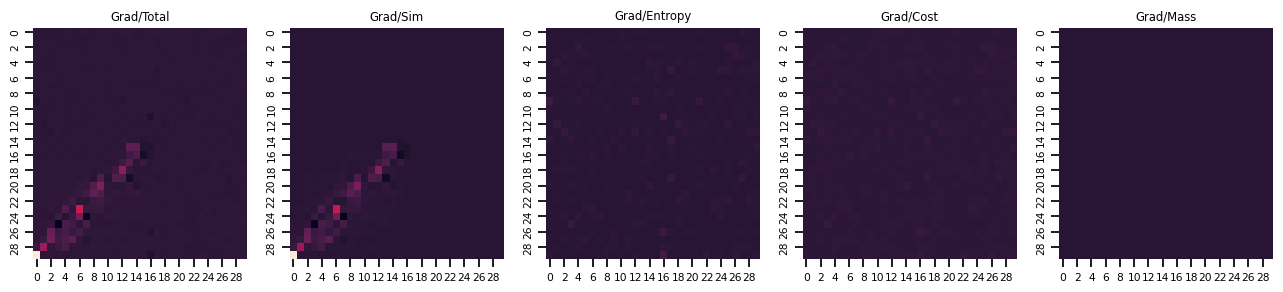

0.0% Loss comb:0.728, Path loss:28.678, Belt penalty:2.02, Mass: 0.00, Entropy:64.61
2.0% Loss comb:-4.920, Path loss:22.994, Belt penalty:2.02, Mass: 0.00, Entropy:64.24
3.9% Loss comb:-9.487, Path loss:18.302, Belt penalty:2.02, Mass: 0.00, Entropy:63.97
5.9% Loss comb:-11.731, Path loss:15.461, Belt penalty:2.02, Mass: 0.00, Entropy:63.22
7.8% Loss comb:-12.985, Path loss:13.981, Belt penalty:2.02, Mass: 0.00, Entropy:62.75
9.8% Loss comb:-16.396, Path loss:10.233, Belt penalty:2.02, Mass: 0.00, Entropy:62.27
11.8% Loss comb:-16.438, Path loss:9.852, Belt penalty:2.02, Mass: 0.00, Entropy:61.80
13.7% Loss comb:-18.247, Path loss:7.691, Belt penalty:2.02, Mass: 0.00, Entropy:61.72
15.7% Loss comb:-18.935, Path loss:6.135, Belt penalty:2.02, Mass: 0.00, Entropy:60.25
17.6% Loss comb:-18.662, Path loss:5.689, Belt penalty:2.02, Mass: 0.00, Entropy:59.39


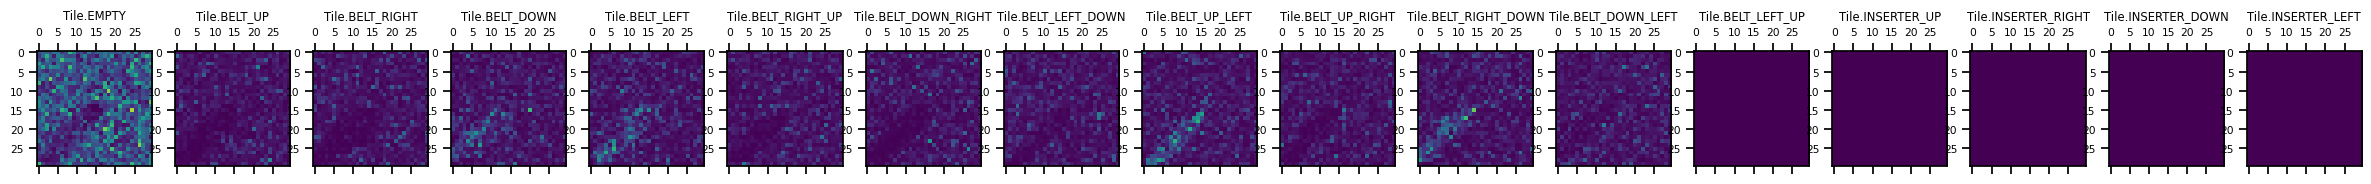

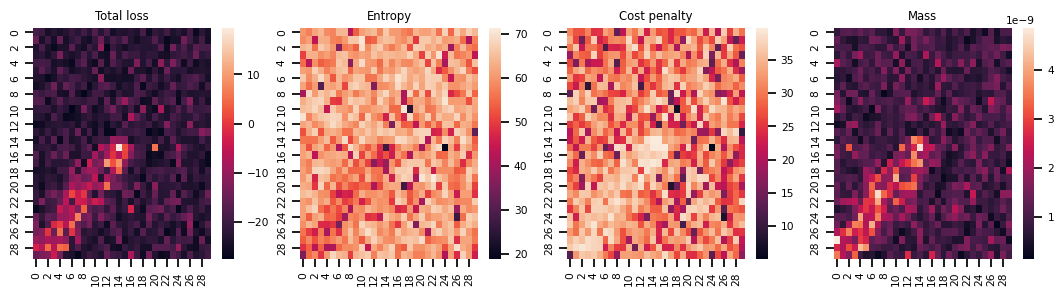

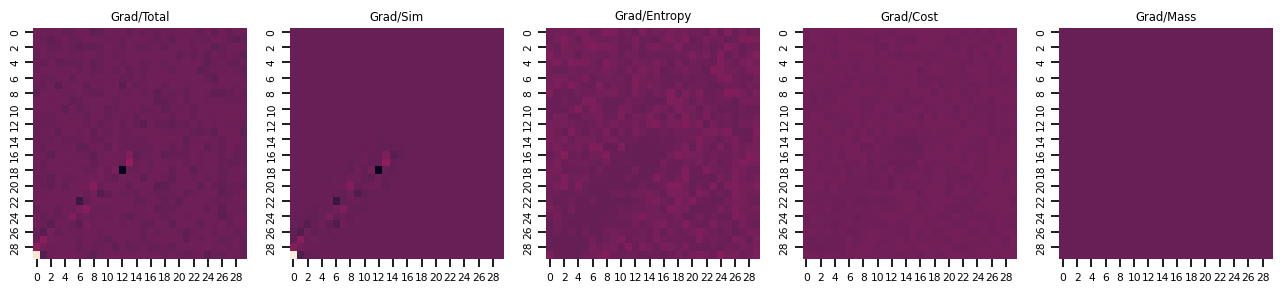

19.6% Loss comb:-19.527, Path loss:4.191, Belt penalty:2.02, Mass: 0.00, Entropy:59.28
21.6% Loss comb:-18.794, Path loss:3.913, Belt penalty:2.02, Mass: 0.00, Entropy:58.41
23.5% Loss comb:-18.280, Path loss:3.426, Belt penalty:2.02, Mass: 0.00, Entropy:57.50
25.5% Loss comb:-17.686, Path loss:3.110, Belt penalty:2.02, Mass: 0.00, Entropy:57.10
27.5% Loss comb:-17.217, Path loss:2.148, Belt penalty:2.02, Mass: 0.00, Entropy:55.98
29.4% Loss comb:-16.178, Path loss:2.009, Belt penalty:2.02, Mass: 0.00, Entropy:55.48
31.4% Loss comb:-15.647, Path loss:1.267, Belt penalty:2.02, Mass: 0.00, Entropy:55.09
33.3% Loss comb:-14.524, Path loss:1.083, Belt penalty:2.02, Mass: 0.00, Entropy:54.84
35.3% Loss comb:-13.570, Path loss:0.403, Belt penalty:2.02, Mass: 0.00, Entropy:53.93
37.3% Loss comb:-12.406, Path loss:0.523, Belt penalty:2.02, Mass: 0.00, Entropy:53.49


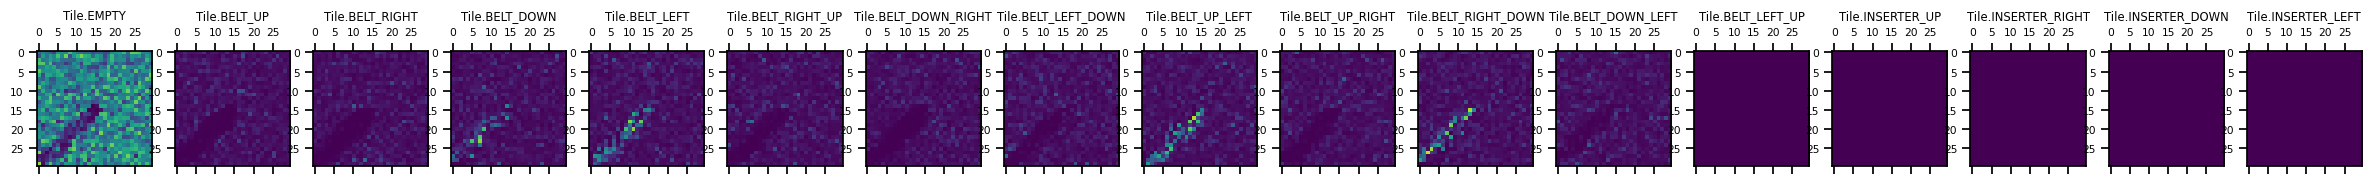

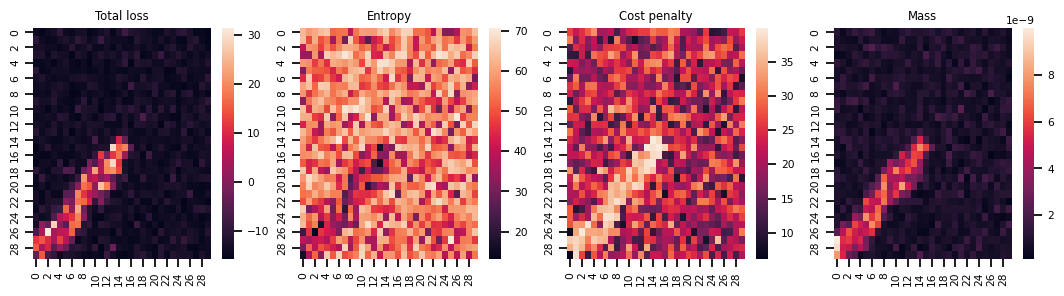

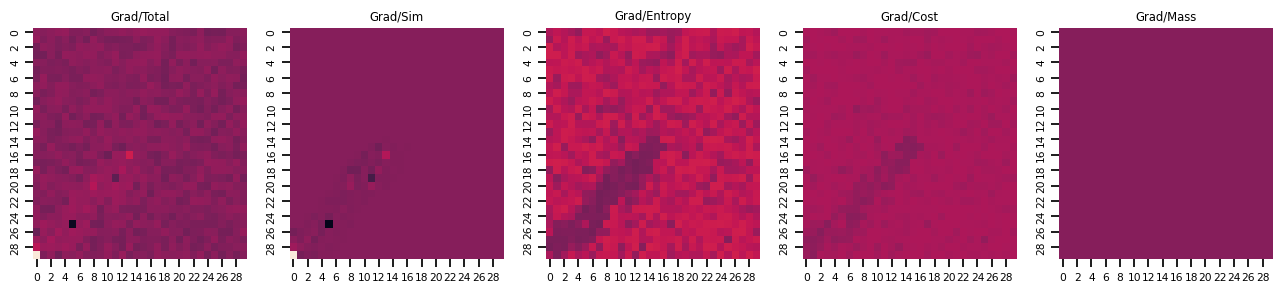

39.2% Loss comb:-11.096, Path loss:0.426, Belt penalty:2.02, Mass: 0.00, Entropy:52.49
41.2% Loss comb:-9.986, Path loss:0.266, Belt penalty:2.02, Mass: 0.00, Entropy:51.63
43.1% Loss comb:-8.749, Path loss:0.215, Belt penalty:2.02, Mass: 0.00, Entropy:49.87
45.1% Loss comb:-7.575, Path loss:0.147, Belt penalty:2.02, Mass: 0.00, Entropy:48.18
47.1% Loss comb:-6.262, Path loss:0.165, Belt penalty:2.02, Mass: 0.00, Entropy:46.95
49.0% Loss comb:-5.168, Path loss:0.119, Belt penalty:2.02, Mass: 0.00, Entropy:44.42
51.0% Loss comb:-4.075, Path loss:0.145, Belt penalty:2.02, Mass: 0.00, Entropy:41.73
52.9% Loss comb:-3.049, Path loss:0.132, Belt penalty:2.02, Mass: 0.00, Entropy:38.69
54.9% Loss comb:-2.088, Path loss:0.155, Belt penalty:2.02, Mass: 0.00, Entropy:34.55
56.9% Loss comb:-1.302, Path loss:0.086, Belt penalty:2.02, Mass: 0.00, Entropy:30.08


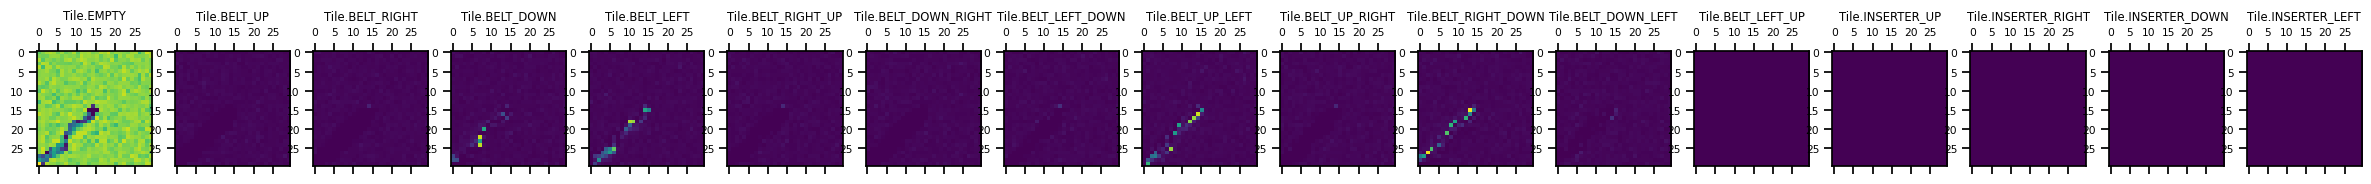

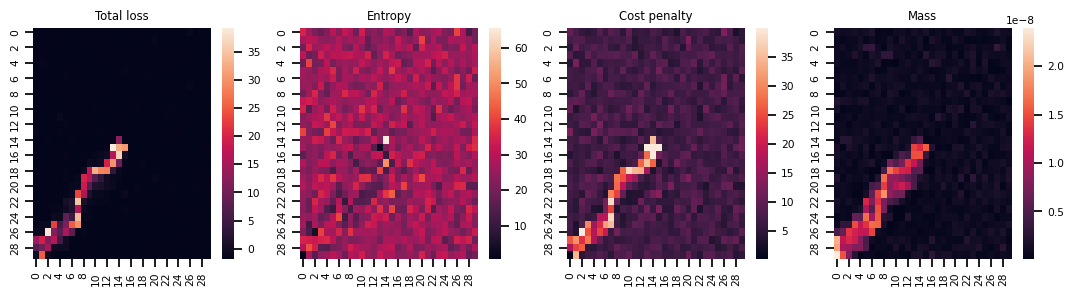

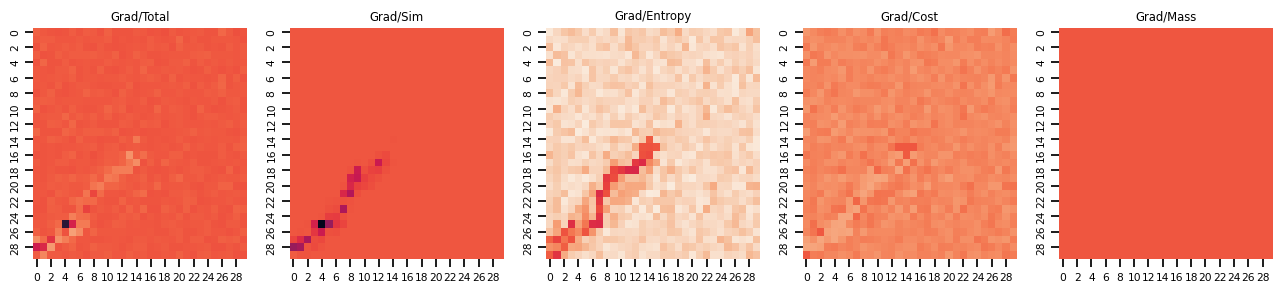

58.8% Loss comb:-0.619, Path loss:0.103, Belt penalty:2.02, Mass: 0.00, Entropy:25.82
60.8% Loss comb:-0.086, Path loss:0.092, Belt penalty:2.02, Mass: 0.00, Entropy:21.33
62.7% Loss comb:0.329, Path loss:0.103, Belt penalty:2.02, Mass: 0.00, Entropy:16.99
64.7% Loss comb:0.609, Path loss:0.069, Belt penalty:2.02, Mass: 0.00, Entropy:12.71
66.7% Loss comb:0.784, Path loss:0.077, Belt penalty:2.02, Mass: 0.00, Entropy:9.24
68.6% Loss comb:0.893, Path loss:0.029, Belt penalty:2.02, Mass: 0.00, Entropy:6.41
70.6% Loss comb:1.228, Path loss:0.466, Belt penalty:2.02, Mass: 0.00, Entropy:4.37
72.5% Loss comb:1.207, Path loss:0.005, Belt penalty:2.02, Mass: 0.00, Entropy:2.71
74.5% Loss comb:1.300, Path loss:0.003, Belt penalty:2.02, Mass: 0.00, Entropy:1.64
76.5% Loss comb:1.311, Path loss:0.002, Belt penalty:2.02, Mass: 0.00, Entropy:1.02


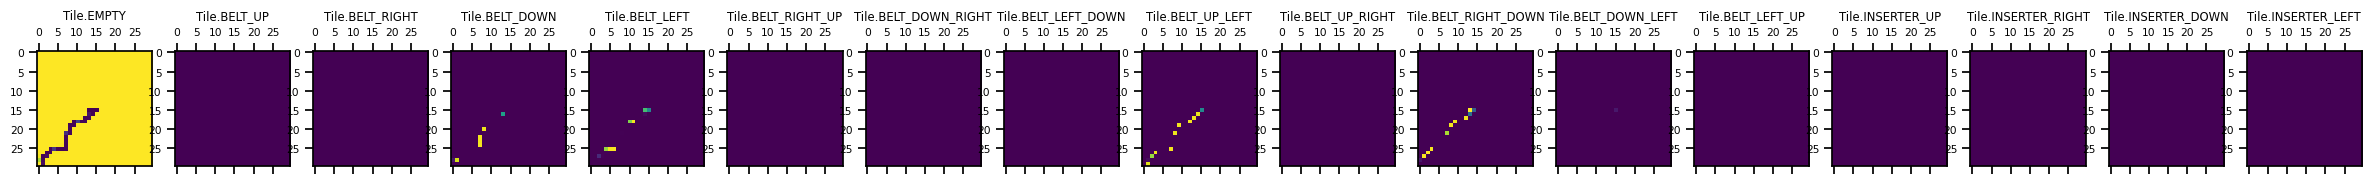

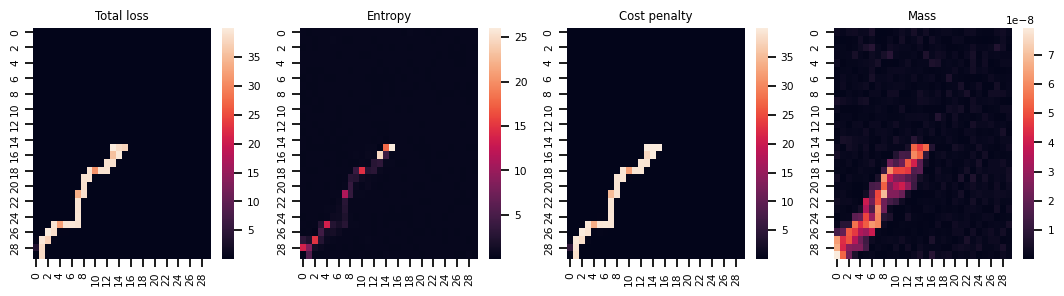

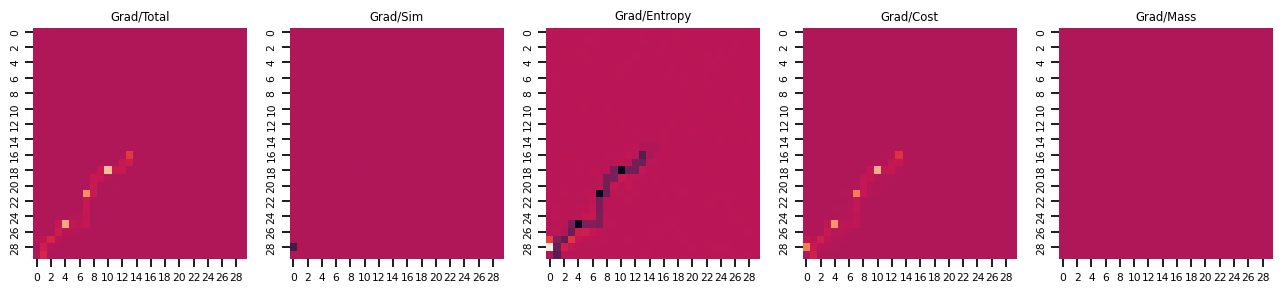

78.4% Loss comb:1.299, Path loss:0.002, Belt penalty:2.02, Mass: 0.00, Entropy:0.66
80.4% Loss comb:1.262, Path loss:0.008, Belt penalty:2.02, Mass: 0.00, Entropy:0.47
82.4% Loss comb:2.242, Path loss:1.038, Belt penalty:2.02, Mass: 0.00, Entropy:0.33
84.3% Loss comb:1.276, Path loss:0.001, Belt penalty:2.02, Mass: 0.00, Entropy:0.26
86.3% Loss comb:1.307, Path loss:0.000, Belt penalty:2.02, Mass: 0.00, Entropy:0.19
88.2% Loss comb:1.311, Path loss:0.000, Belt penalty:2.02, Mass: 0.00, Entropy:0.16
90.2% Loss comb:1.299, Path loss:0.000, Belt penalty:2.02, Mass: 0.00, Entropy:0.14
92.2% Loss comb:1.352, Path loss:0.071, Belt penalty:2.02, Mass: 0.00, Entropy:0.11
94.1% Loss comb:1.304, Path loss:0.000, Belt penalty:2.02, Mass: 0.00, Entropy:0.14
96.1% Loss comb:1.289, Path loss:0.007, Belt penalty:2.02, Mass: 0.00, Entropy:0.14


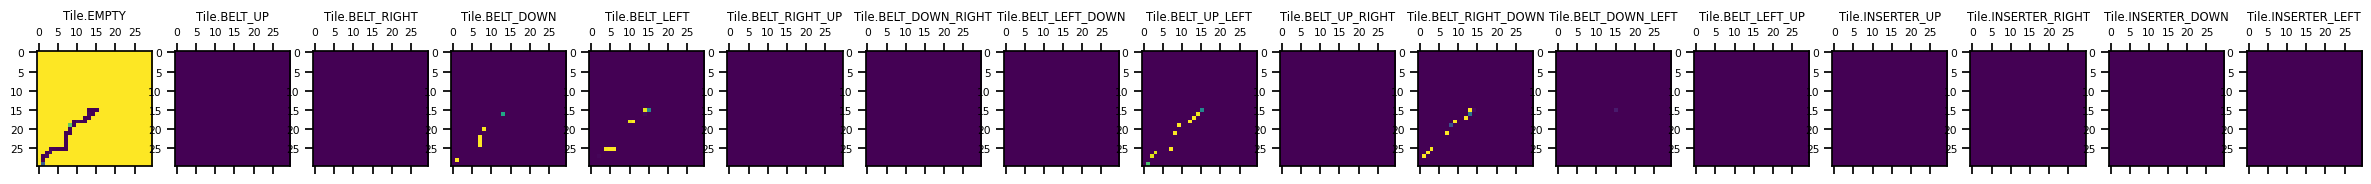

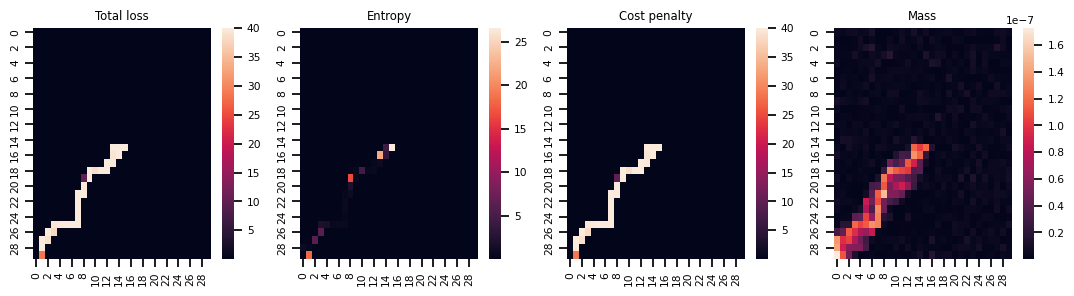

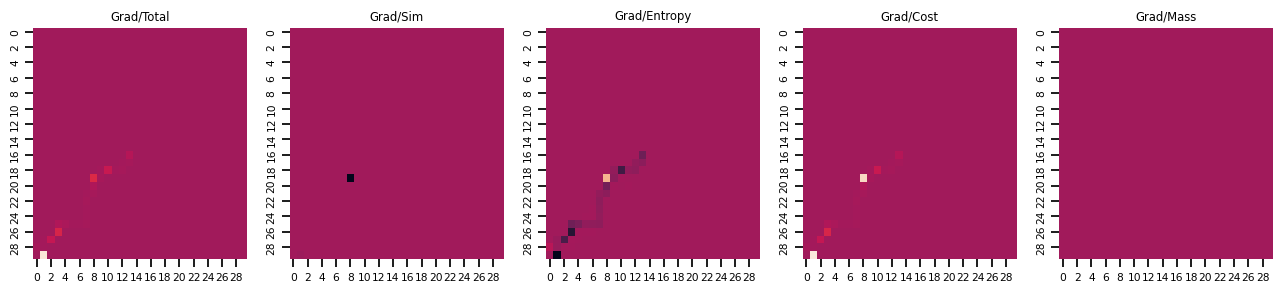

98.0% Loss comb:1.280, Path loss:0.001, Belt penalty:2.02, Mass: 0.00, Entropy:0.14


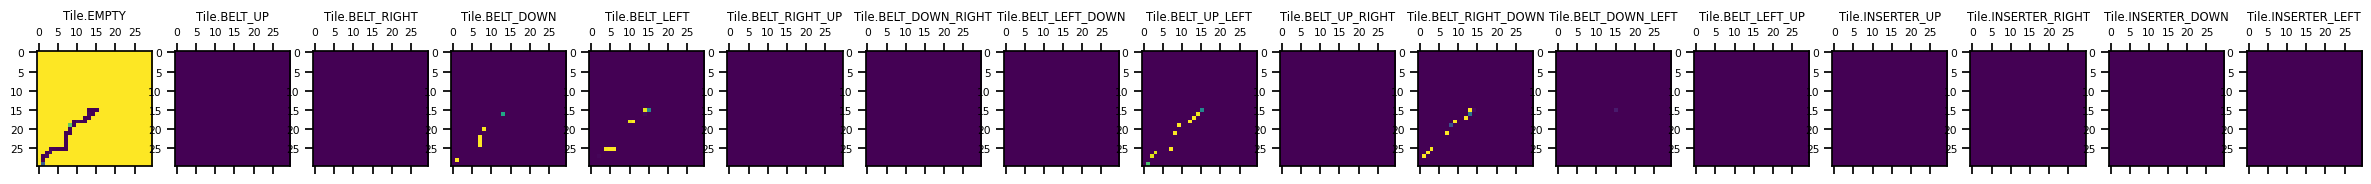

In [ ]:
logits = torch.full((BOX_SIZE,BOX_SIZE,len(Tile)), NEG_INF)
active_tiles = list(range(0,12+1))

logits[:,:,active_tiles] = 5 * torch.randn(BOX_SIZE,BOX_SIZE,len(active_tiles))
logits.requires_grad_()


MAX_ITER = 51

START_TEMP, MIN_TEMP = 100, 20
START_NOISE = 100

MU, SIGMA, RHO = 500, 20000, 40

opt = torch.optim.Adam([logits],lr=25,betas=[0.5,0.9])
for iter in range(MAX_ITER):
    # for g in opt.param_groups:
    #     g['lr'] = 100 * schedule.lr(iter)

    logits_noise = logits + START_NOISE * schedule.noise(iter) * torch.randn_like(logits)

    logits_noise = logits_noise/(MIN_TEMP + (START_TEMP-MIN_TEMP)*schedule.temp(iter))
    with torch.no_grad():
        logits_noise[:, :, 12::] = NEG_INF

    solve_log = torch.nn.functional.log_softmax(logits_noise,dim=-1)

    # Solve: (-inf,0)
    # logits_noise: (0,inf)

    path_loss_log = -sim.eval(solve_log,max_iter=BOX_SIZE*1.8)

    entropy_pc = -( solve_log.exp() * solve_log ).mean(-1) * MU # Shannon entropy - qlogq
        
    cost_penalty_pc = (solve_log.exp()*cost_tensor).sum(-1) * RHO # Linear field

    mass_pc = (logits_noise[:, :, 1:12]**2).mean(-1) / (2*SIGMA**2)

    loss = (path_loss_log.expand_as(entropy_pc)
            + cost_penalty_pc
            + mass_pc
            - schedule.temp(iter)*entropy_pc) # 

    if iter%10==0:
        plot_solve(solve_log)

        fig, ax = plt.subplots(1,4,figsize=(3.5*4, 3*1))
        sns.heatmap(loss.detach().cpu(),           ax=ax[0]).set_title('Total loss')
        sns.heatmap(entropy_pc.detach().cpu(),     ax=ax[1]).set_title('Entropy')
        sns.heatmap(cost_penalty_pc.detach().cpu(),ax=ax[2]).set_title('Cost penalty')
        sns.heatmap(mass_pc.detach().cpu(),        ax=ax[3]).set_title('Mass')
        plt.show()

        plot_grads(logits, {
            'Total': loss.mean(),
            'Sim': path_loss_log,
            'Entropy': entropy_pc.mean(),
            'Cost': cost_penalty_pc.mean(),
            'Mass': mass_pc.mean(),
        })

    

    loss = loss.mean()

    loss.backward()
    opt.step()

    print(f'{iter/MAX_ITER*100:.1f}% Loss comb:{loss.item():.3f}, Path loss:{path_loss_log:.3f}, Belt penalty:{belt_penalty_pc.mean():.2f}, Mass: {mass_pc.mean():.2f}, Entropy:{entropy_pc.mean():.2f}')

    opt.zero_grad()
    # sch.step()

plot_solve(solve_log)

In [ ]:
sim.eval(solve_log, verbose=10,debug=True,max_iter=20)

In [ ]:
render_solve(solve_log)